# UMAP of the RotADeL descriptors

Two-dimensional view of the 18 continuous molecular descriptors, colored by amino acid.

1. Inspect the full library — residue counts and descriptor names.
2. Create two samples (too many rotamers to perform UMAP on all of them):
   - Balanced training subset — max 10'000 rotamers per amino acid (prevents large residue ensembles from dominating UMAP fitting);
   - Balanced display subset — total of 250'000 rotamers distributed as equally between amino acid as availability permits.
3. Standardise and fit UMAP on the balanced training subset — defines the shared two-dimensional coordinate system.
4. Transform the balanced display subset with the fitted scaler and UMAP — no refitting.
5. Plot display subset — two possible colouring:
   - by residue only
   - by rotamer conditional probability

The balanced training subset determines the map; the display subset show views of that map.

In [1]:
from __future__ import annotations

import heapq
import importlib.abc
import json
import sqlite3
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm, to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from seaborn.external.husl import husl_to_rgb, rgb_to_husl


# umap-learn eagerly imports optional TensorFlow-based ParametricUMAP support.
# Block only that unused module to avoid TensorFlow/CUDA/protobuf import noise.
class _BlockParametricUMAP(importlib.abc.MetaPathFinder):
    def find_spec(self, fullname, path=None, target=None):
        if fullname == "umap.parametric_umap":
            raise ImportError("ParametricUMAP is not used in this notebook")


_blocker = _BlockParametricUMAP()
sys.meta_path.insert(0, _blocker)
try:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="IProgress not found.*")
        warnings.filterwarnings("ignore", category=ImportWarning)
        from umap import UMAP
finally:
    sys.meta_path.remove(_blocker)

from rotadel.common.config import SQL_PATH
from rotadel.common.constants import (
    NUMBER_OF_CHI_ANGLES,
    ONE_TO_THREE_AA,
    THREE_TO_ONE_AA,
)

In [2]:
RANDOM_SEED = 42

SQL_PATH = Path(SQL_PATH).resolve()
if not SQL_PATH.is_file():
    raise FileNotFoundError(f"Rotadel database not found: {SQL_PATH}")
print(f"RotADeL sql path: {SQL_PATH}")

FIG_PATH = Path("figures").resolve()
print(f"Path to save plots: {FIG_PATH}")

UMAP_RESULTS_PATH = Path("data/umap_plot_data.pkl").resolve()

RotADeL sql path: /cluster/project/jorner/lajacot/projects/rotadel/database/rotadel.db
Path to save plots: /cluster/project/jorner/lajacot/projects/rotadel/visualisation/distributions/figures


## 1. Inspect library and calculate sampling quotas

- Included descriptors: only molecular descriptors (atomic ones are too AA specific) and exclude total charge (doesn't variate accross rotamers)
- Quotas (number of rotamers per AA to sample)
    - Balanced training subset: sample 10'000 rotamers for each AA, or all rotamers if ensemble <10'000
    - Balanced display subset: sample a total of 250'000 rotamers; all rows from small ensembles, then equal allocation across remaining amino acids

In [3]:
BALANCED_CAP_PER_RESIDUE = 10_000
BALANCED_DISPLAY_SIZE = 250_000


def connect_read_only(path: Path = SQL_PATH) -> sqlite3.Connection:
    return sqlite3.connect(f"file:{path}?mode=ro", uri=True)


def database_summary(path: Path = SQL_PATH) -> tuple[pd.Series, list[str]]:
    """Return residue counts and the continuous molecular descriptor names."""
    with connect_read_only(path) as connection:
        rows = connection.execute(
            "SELECT res, COUNT(*) FROM rotamers_data GROUP BY res ORDER BY res"
        ).fetchall()
        descriptor_json = connection.execute(
            "SELECT descriptors FROM rotamers_data WHERE descriptors IS NOT NULL LIMIT 1"
        ).fetchone()

    if not rows or descriptor_json is None:
        raise ValueError("The database contains no usable rotamer descriptors.")

    counts = pd.Series(dict(rows), name="library_count", dtype="int64")
    example = json.loads(descriptor_json[0])
    names = [
        name
        for name, value in example.items()
        if name != "charge_tot"
        and isinstance(value, (int, float))
        and not isinstance(value, bool)
    ]
    if len(names) != 18:
        raise ValueError(f"Expected 18 continuous descriptors; found {names}")
    return counts, names


def balanced_display_quotas(
    counts: pd.Series, target: int = BALANCED_DISPLAY_SIZE
) -> pd.Series:
    """Distribute the display sample as evenly as residue capacities allow."""
    target = min(target, int(counts.sum()))
    if target < len(counts):
        raise ValueError("Sample target must allow at least one row per residue.")

    quotas = pd.Series(0, index=counts.index, dtype="int64")
    remaining = target
    while remaining:
        active = counts > quotas
        share = remaining // int(active.sum())
        if share == 0:
            quotas.loc[quotas.index[active][:remaining]] += 1
            break
        additions = np.minimum(share, (counts - quotas)[active])
        quotas.loc[active] += additions
        remaining -= int(additions.sum())

    if int(quotas.sum()) != target:
        raise RuntimeError("Could not construct valid balanced display quotas.")
    return quotas

In [4]:
# Calculate balanced training and display quotas
library_counts, descriptor_names = database_summary()
if set(library_counts.index) != set(ONE_TO_THREE_AA.values()):
    raise ValueError("Database residues do not match ONE_TO_THREE_AA.")

training_quotas = library_counts.clip(upper=BALANCED_CAP_PER_RESIDUE).astype("int64")
balanced_display_quotas_by_residue = balanced_display_quotas(library_counts)

In [5]:
# Display sampling statistics
sampling_audit = pd.DataFrame(
    {
        "library_count": library_counts,
        "training_count": training_quotas,
        "balanced_display_count": balanced_display_quotas_by_residue,
    }
)

print(f"Library: {int(library_counts.sum()):,} rotamers")
print(f"Descriptors ({len(descriptor_names)}): {descriptor_names}")
print(f"Balanced training subset: {int(training_quotas.sum()):,}")
print(f"Balanced display subset: {int(balanced_display_quotas_by_residue.sum()):,}")
display(sampling_audit)

Library: 973,247 rotamers
Descriptors (18): ['v_bur', 'sasa_tot', 'sasa_polar', 'sasa_unpolar', 'sterimol_l', 'sterimol_b1', 'sterimol_b5', 'cone_angle', 'p_int', 'homo', 'lumo', 'electron_affinity', 'ionization_potential', 'electronegativity', 'hardness', 'dipole', 'global_nucleophilicity', 'global_electrophilicity']
Balanced training subset: 152,034
Balanced display subset: 250,000


,library_count,training_count,balanced_display_count
ALA,1,1,1
ARG,97200,10000,18604
ASN,46642,10000,18604
ASP,46652,10000,18604
CYS,7776,7776,7776
GLN,139968,10000,18604
GLU,139964,10000,18604
GLY,1,1,1
HIS,139968,10000,18603
ILE,11664,10000,11664


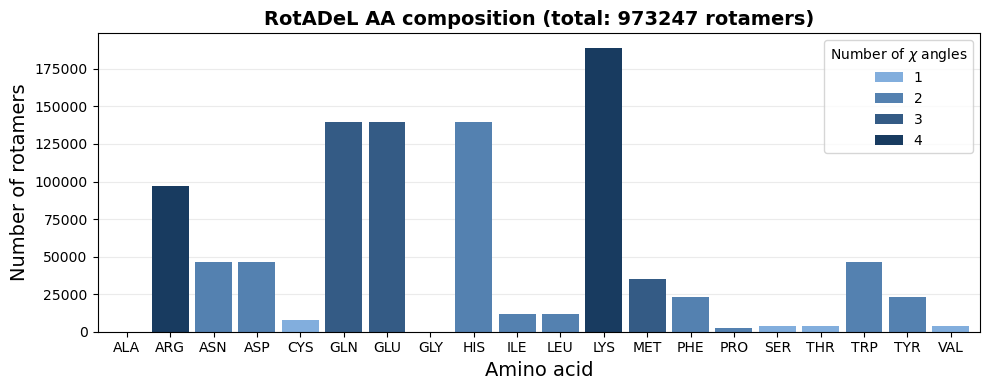

In [6]:
# Plot AA composition, coloured by side-chain flexibility
chi_colors = {
    0: "#96a2af",
    1: "#82aedd",
    2: "#5481b0",
    3: "#345b85",
    4: "#183b60",
}
bar_colors = [
    chi_colors[NUMBER_OF_CHI_ANGLES[THREE_TO_ONE_AA[residue]]]
    for residue in library_counts.index
]

fig, ax = plt.subplots(figsize=(10, 4))
library_counts.plot.bar(ax=ax, color=bar_colors, width=0.85)
ax.set_title(
    f"RotADeL AA composition (total: {int(library_counts.sum())} rotamers)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Amino acid", fontsize=14)
ax.set_ylabel("Number of rotamers", fontsize=14)
ax.tick_params(axis="x", labelrotation=0)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25)
ax.legend(
    handles=[
        Patch(facecolor=chi_colors[n_chi], label=str(n_chi)) for n_chi in range(1, 5)
    ],
    title=r"Number of $\chi$ angles",
    loc="upper right",
    frameon=True,
)
fig.tight_layout()

# Uncomment to save figure
# fig.savefig(FIG_PATH / "aa_composition.png", dpi=600, bbox_inches="tight")

## 2. Extract balanced training and display subsets

In [7]:
FETCH_SIZE = 10_000


def stream_reservoirs(
    names: list[str],
    maximum_quotas: pd.Series,
    path: Path = SQL_PATH,
    seed: int = RANDOM_SEED,
) -> dict[str, list]:
    """Stream the database into reproducible bounded per-residue reservoirs."""
    rng = np.random.default_rng(seed)
    heaps = {residue: [] for residue in maximum_quotas.index}
    processed = 0

    with connect_read_only(path) as connection:
        cursor = connection.execute(
            "SELECT rotamer_id, res, prob, descriptors FROM rotamers_data "
            "WHERE descriptors IS NOT NULL ORDER BY rowid"
        )
        while rows := cursor.fetchmany(FETCH_SIZE):
            for rotamer_id, residue, prob, descriptor_json in rows:
                descriptors = json.loads(descriptor_json)
                values = tuple(float(descriptors[name]) for name in names)
                if (
                    not np.isfinite(values).all()
                    or prob is None
                    or not np.isfinite(prob)
                ):
                    raise ValueError(f"Invalid data in {rotamer_id!r}")

                priority = float(rng.random())
                entry = (
                    -priority,
                    rotamer_id,
                    (rotamer_id, residue, float(prob), *values),
                )
                heap = heaps[residue]
                quota = int(maximum_quotas[residue])
                if len(heap) < quota:
                    heapq.heappush(heap, entry)
                elif entry > heap[0]:
                    heapq.heapreplace(heap, entry)

            processed += len(rows)
            if processed % 200_000 < FETCH_SIZE:
                print(f"Processed {processed} rotamers")
    return heaps


def sample_frame(heaps: dict, quotas: pd.Series, names: list[str]) -> pd.DataFrame:
    """Extract a nested sample from the per-residue reservoirs."""
    records = [
        entry[2]
        for residue, quota in quotas.items()
        for entry in sorted(heaps[residue], reverse=True)[: int(quota)]
    ]
    frame = pd.DataFrame(records, columns=["rotamer_id", "res", "prob", *names])
    if len(frame) != int(quotas.sum()):
        raise RuntimeError("Sample size does not match its quotas.")
    return frame

In [8]:
# Sample balanced training and display subsets
maximum_quotas = pd.concat(
    [training_quotas, balanced_display_quotas_by_residue], axis=1
).max(axis=1)
reservoirs = stream_reservoirs(descriptor_names, maximum_quotas)
training = sample_frame(reservoirs, training_quotas, descriptor_names)
balanced_display = sample_frame(
    reservoirs, balanced_display_quotas_by_residue, descriptor_names
)

print(f"Balanced training subset loaded: {len(training)}")
print(f"Balanced display subset loaded: {len(balanced_display)}")

Processed 200000 rotamers
Processed 400000 rotamers
Processed 600000 rotamers
Processed 800000 rotamers
Balanced training subset loaded: 152034
Balanced display subset loaded: 250000


## 3. Fit UMAP and project both display subsets

1. Fit Standard Scaler on the balanced training descriptors.
2. Fit UMAP on the same balanced scaled training descriptors.
3. Transform both 250000-point display subsets into the shared UMAP space.
4. Omit any points that UMAP marks as disconnected from the manifold.

If `data/umap_plot_data.pkl` exists, load the plot-ready results instead.

In [9]:
# Runtime without cached results: ~ 8 min

COORDINATE_COLUMNS = ["umap_1", "umap_2"]
PLOT_COLUMNS = ["rotamer_id", "res", "prob", *COORDINATE_COLUMNS]

if UMAP_RESULTS_PATH.is_file():
    balanced_display = pd.read_pickle(UMAP_RESULTS_PATH)["balanced_display"].copy()
    print(f"UMAP was not rerun; loaded results from {UMAP_RESULTS_PATH}")
else:
    coordinates_in_memory = set(COORDINATE_COLUMNS).issubset(balanced_display.columns)
    if coordinates_in_memory:
        print("UMAP already ran; reusing its results from memory.")
    else:
        scaler = StandardScaler()
        training_scaled = scaler.fit_transform(training[descriptor_names])
        balanced_scaled = scaler.transform(balanced_display[descriptor_names])
        umap_model = UMAP(
            n_components=2,
            n_neighbors=50,
            min_dist=0.1,
            metric="euclidean",
            init="random",
            random_state=RANDOM_SEED,
            n_jobs=1,
            transform_seed=RANDOM_SEED,
            low_memory=True,
        ).fit(training_scaled)
        balanced_display[COORDINATE_COLUMNS] = umap_model.transform(balanced_scaled)

    finite = np.isfinite(balanced_display[COORDINATE_COLUMNS]).all(axis=1)
    if omitted := int((~finite).sum()):
        print(f"Omitted {omitted:,} disconnected points.")
    balanced_display = balanced_display.loc[finite].copy()

    UMAP_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    pd.to_pickle(
        {"balanced_display": balanced_display[PLOT_COLUMNS]}, UMAP_RESULTS_PATH
    )
    print(f"UMAP results were saved to {UMAP_RESULTS_PATH}")

UMAP was not rerun; loaded results from /cluster/project/jorner/lajacot/projects/rotadel/visualisation/distributions/data/umap_plot_data.pkl


## 4. Plot proportional and balanced display subsets

Two possible displayed data:

- Proportional 250'000 subset — actual library composition
- Balanced 250'000 subset — equalized amino-acid visibility

Two possible colouring schemes:
- Only by amino acid, with each point coloured according to its amino acid
- By amino acid and rotamer probability - one colour hue for each amino acid, and then lightness corresponding to the conditional side-chain probability of this rotamer

In [27]:
# --- For colouring scheme with only amino acid

POINT_SIZE = 3
POINT_ALPHA = 0.6

if "library_counts" in globals():
    residue_order = list(library_counts.index)
else:
    residue_order = sorted(balanced_display["res"].unique())
cmap = plt.get_cmap("tab20", len(residue_order))
residue_colors = {residue: cmap(i) for i, residue in enumerate(residue_order)}
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=residue_colors[residue],
        markeredgecolor="none",
        markersize=8,
        alpha=1.0,
        label=residue,
    )
    for residue in residue_order
]

# --- For colouring scheme with side-chain probability

# Lightness Probability scale: logarithmic
# + clipped to 1e-4 to 1; zero and smaller values use the palest level
PROBABILITY_FLOOR = 1e-4
PROBABILITY_LEVELS = 256  # lightness levels: efficient for 250'000 points
PROBABILITY_SATURATION = 85
PROBABILITY_LIGHTNESS_LOW = 90  # low probability: pale
PROBABILITY_LIGHTNESS_HIGH = 35  # high probability: dark
REFERENCE_LIGHTNESS = 55

HIGHLIGHT_COLOR = "sandybrown"
HIGHLIGHT_RGB = np.asarray(to_rgb(HIGHLIGHT_COLOR))
HIGHLIGHT_HUE, HIGHLIGHT_SATURATION, _ = rgb_to_husl(*HIGHLIGHT_RGB)

# Hue for amino acid: 18 evenly spaced HUSL hues at equal reference lightness
# + ALA/GLY omitted because each has only one geometry
# + no transparency because would interfere with lightness encoding
probability_residues = [
    residue for residue in residue_order if residue not in {"ALA", "GLY"}
]
hue_by_residue = {
    residue: 360 * index / len(probability_residues)
    for index, residue in enumerate(probability_residues)
}
lightness_levels = np.linspace(
    PROBABILITY_LIGHTNESS_LOW,
    PROBABILITY_LIGHTNESS_HIGH,
    PROBABILITY_LEVELS,
)
color_lookup = {
    residue: np.asarray(
        [
            husl_to_rgb(
                hue_by_residue.get(residue, 0),
                PROBABILITY_SATURATION if residue in hue_by_residue else 0,
                lightness,
            )
            for lightness in lightness_levels
        ]
    )
    for residue in residue_order
}
probability_cmap = ListedColormap(
    [husl_to_rgb(0, 0, lightness) for lightness in lightness_levels]
)
highlight_probability_colors = np.asarray(
    [
        husl_to_rgb(HIGHLIGHT_HUE, HIGHLIGHT_SATURATION, lightness)
        for lightness in lightness_levels
    ]
)
highlight_probability_cmap = ListedColormap(highlight_probability_colors)
probability_legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=husl_to_rgb(
            hue_by_residue[residue],
            PROBABILITY_SATURATION,
            REFERENCE_LIGHTNESS,
        ),
        markeredgecolor="none",
        markersize=8,
        label=residue,
    )
    for residue in probability_residues
]


# --- For plotting UMAP


def plot_umap(
    frame: pd.DataFrame,
    title: str | None = None,
    colour_by_prob: bool = False,
    highlight_residue: str | None = None,
    save_path: Path | str | None = None,
) -> None:
    """Plot a UMAP, optionally highlighting one amino acid against grey points."""
    plot_frame = frame.sample(frac=1, random_state=RANDOM_SEED)

    if highlight_residue is not None:
        highlight_residue = highlight_residue.upper()
        if highlight_residue not in residue_colors:
            raise ValueError(
                f"Unknown amino acid {highlight_residue!r}; choose from {residue_order}."
            )
        is_highlighted = plot_frame["res"] == highlight_residue
        plot_frame = pd.concat(
            [plot_frame.loc[~is_highlighted], plot_frame.loc[is_highlighted]]
        )

    if colour_by_prob:
        probabilities = np.clip(
            plot_frame["prob"].to_numpy(dtype=float),
            PROBABILITY_FLOOR,
            1.0,
        )
        probability_strength = (
            np.log10(probabilities) - np.log10(PROBABILITY_FLOOR)
        ) / -np.log10(PROBABILITY_FLOOR)
        level_indices = np.rint(probability_strength * (PROBABILITY_LEVELS - 1)).astype(
            int
        )

        point_colors = np.empty((len(plot_frame), 3))
        residues = plot_frame["res"].to_numpy()
        for residue in residue_order:
            mask = residues == residue
            point_colors[mask] = color_lookup[residue][level_indices[mask]]

        if highlight_residue is None:
            fig = plt.figure(figsize=(12, 8), layout="constrained")
            grid = fig.add_gridspec(
                1, 4, width_ratios=(1, 0.03, 0.035, 0.20), wspace=0.02
            )
            ax = fig.add_subplot(grid[0, 0])
            colorbar_ax = fig.add_subplot(grid[0, 2])
            legend_ax = fig.add_subplot(grid[0, 3])
            legend_ax.axis("off")
        else:
            fig = plt.figure(figsize=(10, 8), layout="constrained")
            grid = fig.add_gridspec(1, 3, width_ratios=(1, 0.03, 0.035), wspace=0.02)
            ax = fig.add_subplot(grid[0, 0])
            colorbar_ax = fig.add_subplot(grid[0, 2])
            legend_ax = ax
        ax.set_anchor("E")
        point_alpha = 1.0
    else:
        point_colors = np.asarray(plot_frame["res"].map(residue_colors).tolist())
        fig, ax = plt.subplots(figsize=(10, 8), layout="constrained")
        legend_ax = ax
        point_alpha = POINT_ALPHA

    if highlight_residue is not None:
        highlight_mask = plot_frame["res"].to_numpy() == highlight_residue
        grey = np.full(point_colors.shape[1], 0.75)
        if point_colors.shape[1] == 4:
            grey[-1] = 1.0
            point_colors[highlight_mask] = np.append(HIGHLIGHT_RGB, 1.0)
        else:
            point_colors[highlight_mask] = highlight_probability_colors[
                level_indices[highlight_mask]
            ]
        point_colors[~highlight_mask] = grey
        highlight_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=HIGHLIGHT_COLOR,
                markeredgecolor="none",
                markersize=8,
                label=f"{highlight_residue} rotamers",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=grey,
                markeredgecolor="none",
                markersize=8,
                label="Other amino acids",
            ),
        ]

    ax.scatter(
        plot_frame["umap_1"],
        plot_frame["umap_2"],
        s=POINT_SIZE,
        alpha=point_alpha,
        color=point_colors,
        edgecolors="none",
        rasterized=True,
    )
    if title is not None:
        ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])

    if highlight_residue is not None:
        legend_ax.legend(
            handles=highlight_handles,
            loc="upper right",
            frameon=False,
            fontsize=12 if colour_by_prob else 13,
        )
    elif colour_by_prob:
        legend_ax.legend(
            handles=probability_legend_handles,
            title="Amino acid",
            loc="center left",
            frameon=False,
            fontsize=12,
            title_fontsize=13,
        )
    else:
        legend_ax.legend(
            handles=legend_handles,
            title="Amino acid",
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=False,
            fontsize=13,
            title_fontsize=14,
        )

    if colour_by_prob:
        colorbar_cmap = (
            highlight_probability_cmap
            if highlight_residue is not None
            else probability_cmap
        )
        probability_mappable = plt.cm.ScalarMappable(
            norm=LogNorm(vmin=PROBABILITY_FLOOR, vmax=1.0),
            cmap=colorbar_cmap,
        )
        colorbar = fig.colorbar(
            probability_mappable,
            cax=colorbar_ax,
            extend="min",
        )
        colorbar.set_label("Conditional side-chain probability", fontsize=14)

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

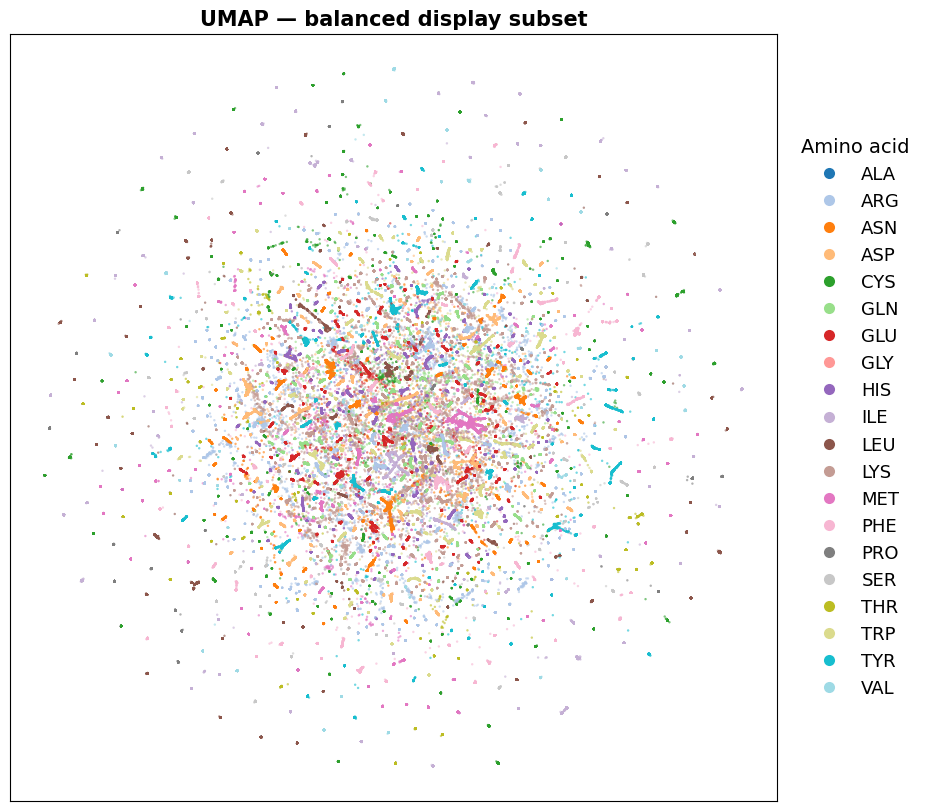

In [11]:
plot_umap(
    balanced_display,
    "UMAP — balanced display subset",
)

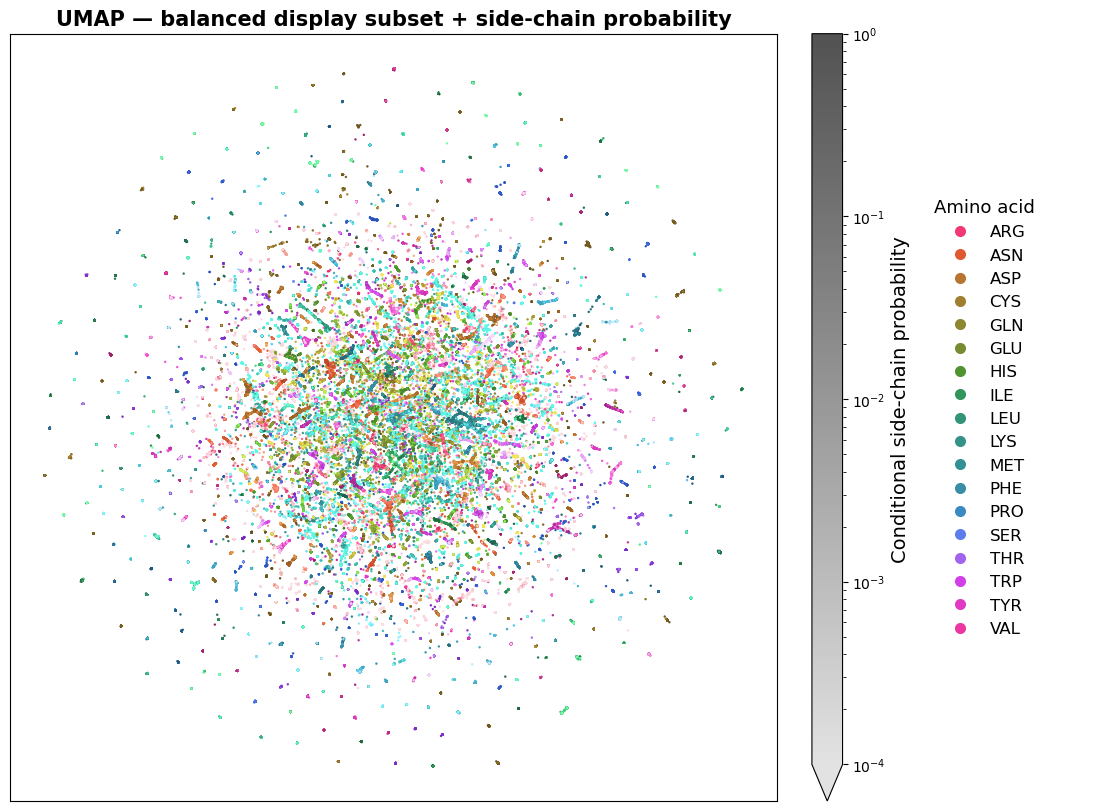

In [29]:
plot_umap(
    balanced_display,
    "UMAP — balanced display subset + side-chain probability",
    colour_by_prob=True,
)

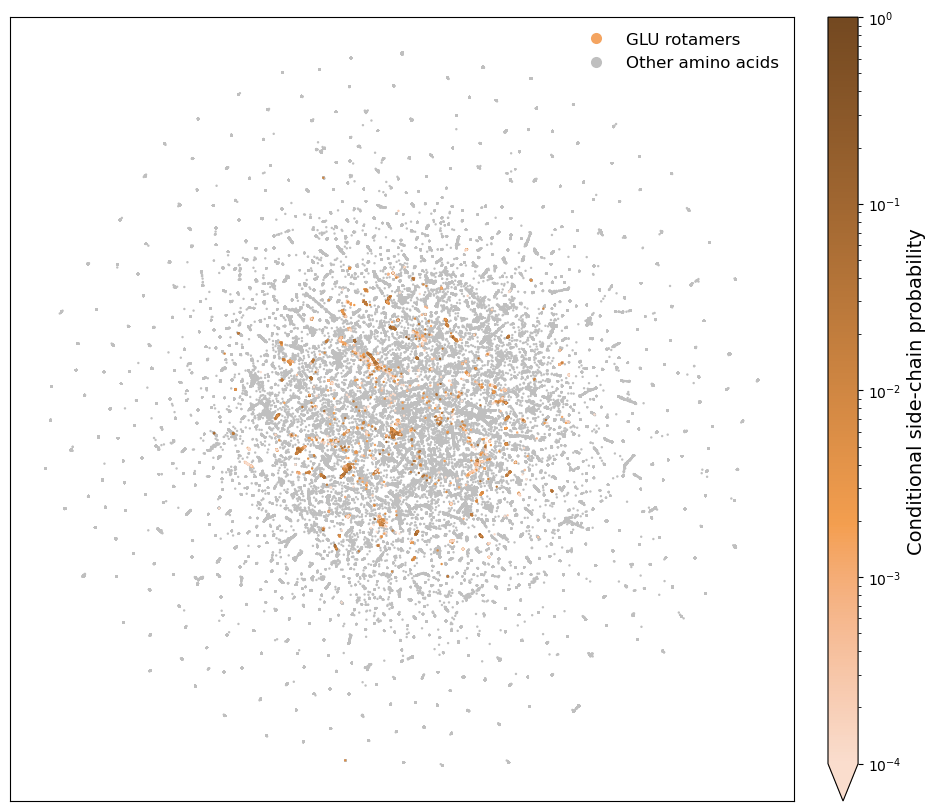

In [28]:
plot_umap(
    balanced_display,
    colour_by_prob=True,
    highlight_residue="GLU",
    save_path=FIG_PATH / "umap_glu.png",
)